# Feature Engineering: Encoding Substructures
Scenario: You are investigating toxicity and its dependency on molecular structure. Using the LD50 Toxicity dataset by Zhu (as provided here: https://huggingface.co/datasets/scikit-fingerprints/TDC_ld50_zhu/viewer), you calculate various molecular descriptors based on the SMILES and train a Random Forest Regressor to predict toxicity. You want to see if there is an improvement of the model when you take into account chemical structure - and generally, whether chemical structure is generally related to toxicity.

Note: the dataset is based on sparse chemical space and will not deliver super high prediction scores.

#### Tasks:
1) Load and inspect the dataset `tdc_ld50_zhu.csv`.
2) Feature engineering: Create a feature matrix `X_md` by calculating descriptors (full list as in rdkit) (Snippet provided)

3) Finding common substructures (functional groups, common scaffolds) is an alternative to detecting similarities based on fingerprints. Use the provided snippets to create different structure-based features and use one-hot encoding to make them more accessible also for other models.

4) Compare the prediction performance of the model for each of the feature matrices and combinations thereof:
- X_md: molecular descriptors only
- X_scaf: One-Hot-encoded Murcko scaffolds
- X_fg: One-hot-encoded functional groups
- X_md_scaf: Concatenation of X_md and X_scaf
- X_md_scaf_fg: Concatenation of X_md, X_scaf and X_fg

Note: For every different dataset you have to perform a train-test split and train the model before predicting. You do not need to use the suggested names!

5) Pick the best one and remove low-variance features (threshold 1%), as well as highly correlated ones (threshold 90%). See if the performance of the predictions by the model improves. Hint: Use `VarianceThreshold` (Unsupervised Algorithm from Scikit-learn) and `corr_matrix = X.corr().abs()` to do so (e.g. similarly as used in the Clustering example on the ESOL dataset)

6) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.

7) Use Butina clustering on UMAP visualisation of the smiles-fingerprint space (scatterplot) and compare the plot side by side (e.g. as suplots) with a scatterplot colourmapped to the toxicity (look at options such as `colorbar` for matplotlib for better visualisation). 

8) Repeat 6 and 7 for the fingerprints based on the Murcko Scaffolds from task 3

9) Respond to the discussion points


Import dependencies and datasets

In [1]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import MolFromSmarts
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder

from sklearn.manifold import TSNE
import umap

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit.ML.Cluster import Butina

1) Load and investigate the data

In [2]:
tox = pd.read_csv("tdc_ld50_zhu.csv")
tox.head()

,smiles,ld_50
0,[O-][N+](=Nc1ccccc1)c1ccccc1,2.505
1,BrC(Br)Br,2.343
2,C=CBr,2.330
3,Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465
4,S=C=Nc1ccc(Br)cc1,2.729


In [3]:
tox.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7376 entries, 0 to 7375
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   smiles  7376 non-null   object 
 1   ld_50   7376 non-null   float64
dtypes: float64(1), object(1)
memory usage: 115.4+ KB


In [4]:
tox.describe()

,ld_50
count,7376.000000
mean,2.544235
std,0.959086
min,-0.343000
25%,1.855750
50%,2.367000
75%,3.035000
max,10.207000


In [5]:
tox.duplicated().sum()

np.int64(0)

In [6]:
tox.isna().sum()

smiles    0
ld_50     0
dtype: int64

2) Calculate descriptors

In [7]:
descriptor_names = [d[0] for d in Descriptors._descList]

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return [desc[1](mol) for desc in Descriptors._descList]

X_md = tox.smiles.apply(calc_descriptors)

X_md = pd.DataFrame(X_md.tolist(), columns=descriptor_names)
X_md = X_md.dropna()

y = tox["ld_50"]

In [8]:
X_md

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.564078,11.564078,0.529031,0.529031,0.412358,11.333333,198.225,188.145,198.079313,74,...,0,0,0,0,0,0,0,0,0,0
1,3.104167,3.104167,0.270833,0.270833,0.581278,9.000000,252.731,251.723,249.762836,26,...,0,0,0,0,0,0,0,0,0,0
2,3.277778,3.277778,1.562500,1.562500,0.439824,4.333333,106.950,103.926,105.941812,18,...,0,0,0,0,0,0,0,0,0,0
3,3.620234,3.620234,1.005501,1.005501,0.282041,10.777778,627.588,623.556,621.541323,94,...,0,0,0,0,0,0,0,0,0,0
4,4.438473,4.438473,0.831667,0.831667,0.516140,8.500000,214.087,210.055,212.924782,50,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7371,12.181890,12.181890,0.412037,-4.489144,0.490490,10.692308,187.120,183.088,187.024498,68,...,0,0,0,0,0,0,0,0,0,0
7372,12.453604,12.453604,0.222420,-4.565243,0.609985,11.800000,224.157,216.093,224.057276,84,...,0,0,0,0,0,0,0,0,0,0
7373,10.682705,10.682705,0.279357,-0.279357,0.703541,9.411765,232.283,216.155,232.121178,90,...,0,0,0,0,0,0,0,0,0,0
7374,12.664707,12.664707,0.156420,-0.156420,0.618330,20.653846,348.446,324.254,348.183778,134,...,0,0,0,0,0,0,0,0,0,0


3) Find common scaffolds and encode them as binary vecotrs (one-hot-encoding). Note that the Scaffolds are represented as SMILES and can be used for fingerprints later

In [9]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

tox["scaffold"] = tox["smiles"].apply(get_scaffold).astype(str)

In [10]:
print(tox["scaffold"].value_counts(dropna=False).head(20))

scaffold
                        1936
c1ccccc1                1539
c1ccc2[nH]cnc2c1         131
c1ccncc1                  85
C1CCCCC1                  81
c1ccc2ccccc2c1            76
c1ccc(Cc2ccccc2)cc1       56
O=c1cccn[nH]1             55
c1ccc(-c2ccccc2)cc1       48
c1ccc(Oc2ccccc2)cc1       45
C1CO1                     37
C1=CCCCC1                 37
c1ncncn1                  35
c1ccc(Nc2ccccc2)cc1       34
c1ccc(CC2=NCCCN2)cc1      30
O=C1NC(=O)c2ccccc21       28
c1nncs1                   26
c1ccc2c(c1)OCO2           25
O=c1ccc2ccccc2o1          23
c1ccoc1                   23
Name: count, dtype: int64


In [11]:
tox.isna().sum()

smiles      0
ld_50       0
scaffold    0
dtype: int64

OneHotEncoder for the Murcko scaffolds:

In [12]:
# OneHotEcoder
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_scaf = encoder.fit_transform(tox[["scaffold"]])
X_scaf

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(7376, 1677))

In [13]:
X_scaf_df = pd.DataFrame(
    X_scaf,
    columns=encoder.get_feature_names_out(["scaffold"]),
    index=tox.index
)
X_scaf_df

,scaffold_,scaffold_C(#Cc1ccccc1)Cc1ccccc1,scaffold_C(=C(c1ccccc1)c1ccccc1)c1ccccc1,scaffold_C(=C1SCC(c2ccccc2)S1)n1ccnc1,scaffold_C(=CSSCC1CCCO1)NCc1cncnc1,scaffold_C(=Cc1ccccc1)C(C=Cc1ccccc1)=NN=C1NCCCN1,scaffold_C(=Cc1ccccc1)CN1CCN(c2cccnn2)CC1,scaffold_C(=Cc1ccccc1)c1ccccc1,scaffold_C(=Cc1ccco1)c1ccccn1,scaffold_C(=Cc1ccco1)c1ccco1,...,scaffold_c1ncn(C2CCCO2)n1,scaffold_c1ncnc(N(CCCCCCN(c2ncncn2)C2CCNCC2)C2CCNCC2)n1,scaffold_c1ncnc(NC2CC2)n1,scaffold_c1ncncn1,scaffold_c1ncsn1,scaffold_c1nnc(NCNc2nncs2)s1,scaffold_c1nnc[nH]1,scaffold_c1nnco1,scaffold_c1nncs1,scaffold_n1o[nH+]c2c1c1[nH+]onc1c1[nH+]onc21
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7372,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7373,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7374,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Instead of structural scaffolds (via SMARTS), encode functional groups using the one-hot-encoder. Add some more functional groups that you think have impact on the toxicity of compounds.

In [14]:
functional_groups = {
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "carboxylic_acid": "C(=O)[OX2H1]",
    "aromatic_ring": "a",
    "halogen": "[F,Cl,Br,I]",
    "epoxide": "C1OC1"
}

In [15]:
patterns = {k: Chem.MolFromSmarts(v) for k,v in functional_groups.items()}

def detect_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return {
        name: int(mol.HasSubstructMatch(pat))
        for name, pat in patterns.items()
    }

X_fg = pd.DataFrame(
    tox["smiles"].apply(detect_groups).tolist()
)
X_fg

,amine,carboxylic_acid,aromatic_ring,halogen,epoxide
0,0,0,1,0,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,1,1,0
4,0,0,1,1,0
...,...,...,...,...,...
7371,0,0,1,1,0
7372,1,0,1,1,0
7373,0,0,1,0,0
7374,0,0,1,0,0


Concatinations

In [16]:
X_md_scaf = pd.concat([X_md, X_scaf_df], axis=1)
X_md_scaf

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,scaffold_c1ncn(C2CCCO2)n1,scaffold_c1ncnc(N(CCCCCCN(c2ncncn2)C2CCNCC2)C2CCNCC2)n1,scaffold_c1ncnc(NC2CC2)n1,scaffold_c1ncncn1,scaffold_c1ncsn1,scaffold_c1nnc(NCNc2nncs2)s1,scaffold_c1nnc[nH]1,scaffold_c1nnco1,scaffold_c1nncs1,scaffold_n1o[nH+]c2c1c1[nH+]onc1c1[nH+]onc21
0,11.564078,11.564078,0.529031,0.529031,0.412358,11.333333,198.225,188.145,198.079313,74,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3.104167,3.104167,0.270833,0.270833,0.581278,9.000000,252.731,251.723,249.762836,26,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.277778,3.277778,1.562500,1.562500,0.439824,4.333333,106.950,103.926,105.941812,18,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.620234,3.620234,1.005501,1.005501,0.282041,10.777778,627.588,623.556,621.541323,94,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.438473,4.438473,0.831667,0.831667,0.516140,8.500000,214.087,210.055,212.924782,50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7371,12.181890,12.181890,0.412037,-4.489144,0.490490,10.692308,187.120,183.088,187.024498,68,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7372,12.453604,12.453604,0.222420,-4.565243,0.609985,11.800000,224.157,216.093,224.057276,84,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7373,10.682705,10.682705,0.279357,-0.279357,0.703541,9.411765,232.283,216.155,232.121178,90,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7374,12.664707,12.664707,0.156420,-0.156420,0.618330,20.653846,348.446,324.254,348.183778,134,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
X_md_scaf_fg = pd.concat([X_md_scaf, X_fg], axis=1)
X_md_scaf_fg

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,scaffold_c1nnc(NCNc2nncs2)s1,scaffold_c1nnc[nH]1,scaffold_c1nnco1,scaffold_c1nncs1,scaffold_n1o[nH+]c2c1c1[nH+]onc1c1[nH+]onc21,amine,carboxylic_acid,aromatic_ring,halogen,epoxide
0,11.564078,11.564078,0.529031,0.529031,0.412358,11.333333,198.225,188.145,198.079313,74,...,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0
1,3.104167,3.104167,0.270833,0.270833,0.581278,9.000000,252.731,251.723,249.762836,26,...,0.0,0.0,0.0,0.0,0.0,0,0,0,1,0
2,3.277778,3.277778,1.562500,1.562500,0.439824,4.333333,106.950,103.926,105.941812,18,...,0.0,0.0,0.0,0.0,0.0,0,0,0,1,0
3,3.620234,3.620234,1.005501,1.005501,0.282041,10.777778,627.588,623.556,621.541323,94,...,0.0,0.0,0.0,0.0,0.0,0,0,1,1,0
4,4.438473,4.438473,0.831667,0.831667,0.516140,8.500000,214.087,210.055,212.924782,50,...,0.0,0.0,0.0,0.0,0.0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7371,12.181890,12.181890,0.412037,-4.489144,0.490490,10.692308,187.120,183.088,187.024498,68,...,0.0,0.0,0.0,0.0,0.0,0,0,1,1,0
7372,12.453604,12.453604,0.222420,-4.565243,0.609985,11.800000,224.157,216.093,224.057276,84,...,0.0,0.0,0.0,0.0,0.0,1,0,1,1,0
7373,10.682705,10.682705,0.279357,-0.279357,0.703541,9.411765,232.283,216.155,232.121178,90,...,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0
7374,12.664707,12.664707,0.156420,-0.156420,0.618330,20.653846,348.446,324.254,348.183778,134,...,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0


4. Training RF on different data sets

In [18]:
# For X_fg
X_fg_train, X_fg_test, y_fg_train, y_fg_test = train_test_split(
    X_fg, y,
    test_size=0.3,
    random_state=42,
)

# For X_md
X_md_train, X_md_test, y_md_train, y_md_test = train_test_split(
    X_md, y,
    test_size=0.3,
    random_state=42,
)

# For X_scaf_df
X_scaf_train, X_scaf_test, y_scaf_train, y_scaf_test = train_test_split(
    X_scaf_df, y,
    test_size=0.3,
    random_state=42,
)

# For X_md_scaf
X_md_scaf_train, X_md_scaf_test, y_md_scaf_train, y_md_scaf_test = train_test_split(
    X_md_scaf, y,
    test_size=0.3,
    random_state=42,
)

# For X_md_scaf_fg
X_md_scaf_fg_train, X_md_scaf_fg_test, y_md_scaf_fg_train, y_md_scaf_fg_test = train_test_split(
    X_md_scaf_fg, y,
    test_size=0.3,
    random_state=42,
)

In [19]:
# Random Forest Regressor

from sklearn.metrics import r2_score, mean_squared_error

rf_default = RandomForestRegressor(random_state=42)

# For X_fg
rf_default.fit(X_fg_train, y_fg_train)
y_pred_test_fg = rf_default.predict(X_fg_test) 
y_pred_train_fg = rf_default.predict(X_fg_train) 

# For X_md
rf_default.fit(X_md_train, y_md_train)
y_pred_test_md = rf_default.predict(X_md_test)
y_pred_train_md = rf_default.predict(X_md_train)

# For X_scaf_df
rf_default.fit(X_scaf_train, y_scaf_train)
y_pred_test_scaf = rf_default.predict(X_scaf_test)
y_pred_train_scaf = rf_default.predict(X_scaf_train)

# For X_md_scaf
rf_default.fit(X_md_scaf_train, y_md_scaf_train)
y_pred_test_md_scaf = rf_default.predict(X_md_scaf_test)
y_pred_train_md_scaf = rf_default.predict(X_md_scaf_train)

# For X_md_scaf_fg
rf_default.fit(X_md_scaf_fg_train, y_md_scaf_fg_train)
y_pred_test_md_scaf_fg = rf_default.predict(X_md_scaf_fg_test)
y_pred_train_md_scaf_fg = rf_default.predict(X_md_scaf_fg_train)

print("Functional Group:")
print("Train RMSE:", np.sqrt(mean_squared_error(y_fg_train, y_pred_train_fg)))
print("Train R2:", r2_score(y_fg_train, y_pred_train_fg))
print("Test RMSE:", np.sqrt(mean_squared_error(y_fg_test, y_pred_test_fg)))
print("Test R2:", r2_score(y_fg_test, y_pred_test_fg))
print("------------------------------------------------")
print("Molecular Descriptor:")
print("Train RMSE:", np.sqrt(mean_squared_error(y_md_train, y_pred_train_md)))
print("Train R2:", r2_score(y_md_train, y_pred_train_md))
print("Test RMSE:", np.sqrt(mean_squared_error(y_md_test, y_pred_test_md)))
print("Test R2:", r2_score(y_md_test, y_pred_test_md))
print("------------------------------------------------")
print("Scaffold:")
print("Train RMSE:", np.sqrt(mean_squared_error(y_scaf_train, y_pred_train_scaf)))
print("Train R2:", r2_score(y_scaf_train, y_pred_train_scaf))
print("Test RMSE:", np.sqrt(mean_squared_error(y_scaf_test, y_pred_test_scaf)))
print("Test R2:", r2_score(y_scaf_test, y_pred_test_scaf))
print("------------------------------------------------")
print("Molecular Descriptor + Scaffold:")
print("Train RMSE:", np.sqrt(mean_squared_error(y_md_scaf_train, y_pred_train_md_scaf)))
print("Train R2:", r2_score(y_md_scaf_train, y_pred_train_md_scaf))
print("Test RMSE:", np.sqrt(mean_squared_error(y_md_scaf_test, y_pred_test_md_scaf)))
print("Test R2:", r2_score(y_md_scaf_test, y_pred_test_md_scaf))
print("------------------------------------------------")
print("Molecular Descriptor + Scaffold + Functional Group:")
print("Train RMSE:", np.sqrt(mean_squared_error(y_md_scaf_fg_train, y_pred_train_md_scaf_fg)))
print("Train R2:", r2_score(y_md_scaf_fg_train, y_pred_train_md_scaf_fg))
print("Test RMSE:", np.sqrt(mean_squared_error(y_md_scaf_fg_test, y_pred_test_md_scaf_fg)))
print("Test R2:", r2_score(y_md_scaf_fg_test, y_pred_test_md_scaf_fg))

Functional Group:
Train RMSE: 0.9261937581037951
Train R2: 0.057397188737595584
Test RMSE: 0.9415192671608016
Test R2: 0.05894920899644773
------------------------------------------------
Molecular Descriptor:
Train RMSE: 0.22642656662132774
Train R2: 0.9436648060867198
Test RMSE: 0.6267441514493345
Test R2: 0.583000801326103
------------------------------------------------
Scaffold:
Train RMSE: 0.746348772959378
Train R2: 0.3879193117030819
Test RMSE: 0.8878189730779837
Test R2: 0.1632350427063598
------------------------------------------------
Molecular Descriptor + Scaffold:
Train RMSE: 0.22591302612048345
Train R2: 0.943920055254062
Test RMSE: 0.6297915655473477
Test R2: 0.5789357975744477
------------------------------------------------
Molecular Descriptor + Scaffold + Functional Group:
Train RMSE: 0.22530285560962005
Train R2: 0.9442225798036817
Test RMSE: 0.6304437846171711
Test R2: 0.5780632285520007


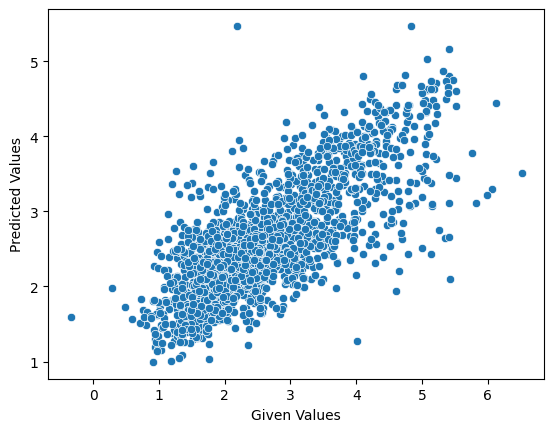

In [20]:
sns.scatterplot(x=y_md_test, y=y_pred_test_md)
plt.xlabel("Given Values")
plt.ylabel("Predicted Values")
plt.show()

5) Pick the best one and prune the features regarding variance and correlation. Run the regression model again and compare the performance.

In [21]:
from sklearn.feature_selection import VarianceThreshold

var_filter = VarianceThreshold(threshold=0.01)
X_train_var = var_filter.fit_transform(X_md_train)
X_test_var = var_filter.transform(X_md_test)

kept_cols = X_md_train.columns[var_filter.get_support()]

X_train_var = pd.DataFrame(X_train_var, columns=X_md_train.columns[var_filter.get_support()])
X_test_var = pd.DataFrame(X_test_var, columns=X_md_test.columns[var_filter.get_support()])

print("After variance filter:", X_train_var.shape, X_test_var.shape)

After variance filter: (5163, 192) (2213, 192)


In [22]:
corr_matrix = X_train_var.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

X_train_final_md = X_train_var.drop(columns=to_drop)
X_test_final_md = X_test_var.drop(columns=to_drop)

print("After correlation filtering:", X_train_final_md.shape, X_test_final_md.shape)

After correlation filtering: (5163, 152) (2213, 152)


In [23]:
# Training again with pruned features

rf_default.fit(X_train_final_md, y_md_train)
y_pred_test_md_2 = rf_default.predict(X_test_final_md)
y_pred_train_md_2 = rf_default.predict(X_train_final_md)

print("Molecular Descriptor (Pruned):")
print("Train RMSE:", np.sqrt(mean_squared_error(y_md_train, y_pred_train_md_2)))
print("Train R2:", r2_score(y_md_train, y_pred_train_md_2))
print("Test RMSE:", np.sqrt(mean_squared_error(y_md_test, y_pred_test_md_2)))
print("Test R2:", r2_score(y_md_test, y_pred_test_md_2))

Molecular Descriptor (Pruned):
Train RMSE: 0.22654243126475074
Train R2: 0.9436071368186444
Test RMSE: 0.6251748178196277
Test R2: 0.5850864739557755


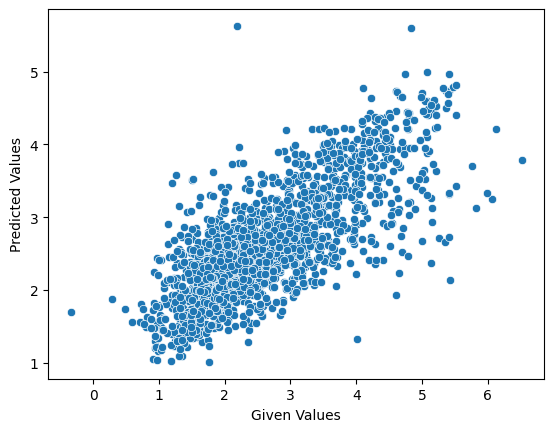

In [24]:
sns.scatterplot(x=y_md_test, y=y_pred_test_md_2)
plt.xlabel("Given Values")
plt.ylabel("Predicted Values")
plt.show()

pretty much the same. very slight improvement

6) Generate Morgan fingerprints (2048 bit, radius=2) for both "smiles" (entire molecules) and "scaffolds" (SMILES of common scaffolds only)

In [25]:
# Fingerprint generator
def mol2fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)
    fp = mfpgen.GetFingerprint(mol)
    return fp

tox["fingerprint_smiles"] = tox["smiles"].apply(mol2fp)
tox["fingerprint_scaffold"] = tox["scaffold"].apply(mol2fp)

7) Butina clustering (as in last exercise): Experiment with different cutoffs and filter limits for the clusters (compare in the visualisation, no need to rerun the UMAP visualisation in between)

In [26]:
dists = []
nfps = len(tox["fingerprint_smiles"])
cutoff = 0.6

for i in range(1, nfps):
    sims = DataStructs.BulkTanimotoSimilarity(tox["fingerprint_smiles"].iloc[i], tox["fingerprint_smiles"].iloc[:i])
    dists.extend([1-x for x in sims])

clusters = Butina.ClusterData(
    dists,
    nfps,
    cutoff,
    isDistData=True
)


dists2 = []
nfps2 = len(tox["fingerprint_scaffold"])
cutoff = 0.6

for i in range(1, nfps2):
    sims = DataStructs.BulkTanimotoSimilarity(tox["fingerprint_scaffold"].iloc[i], tox["fingerprint_scaffold"].iloc[:i])
    dists2.extend([1-x for x in sims])

clusters2 = Butina.ClusterData(
    dists2,
    nfps2,
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(clusters))
print("Number of clusters:", len(clusters2))

Number of clusters: 2408
Number of clusters: 747


In [27]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered = [c for c in clusters if len(c) >= 5]

butina_labels = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered):
    for id in cluster:
        butina_labels[id] = cluster_id

sizes = [len(c) for c in clusters_filtered]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters_filtered2 = [c for c in clusters2 if len(c) >= 5]

butina_labels2 = np.full(nfps2, -1)
for cluster_id, cluster in enumerate(clusters_filtered2):
    for id in cluster:
        butina_labels2[id] = cluster_id

sizes2 = [len(c) for c in clusters_filtered2]
print("-------------------------------------------")
print("clusters:", len(sizes2))
print("mean size:", np.mean(sizes2))
print("max size:", np.max(sizes2))
print("singletons:", sum(s == 1 for s in sizes2))

clusters: 334
mean size: 12.769461077844312
max size: 112
singletons: 0
-------------------------------------------
clusters: 161
mean size: 40.27329192546584
max size: 1936
singletons: 0


Calculate UMAP space - play with `n_neighbors` and `min_distance` until you are satisfied with the visualisation.

In [28]:
# convert fingerprints to numpy
fp_array = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(tox["fingerprint_smiles"]):
    DataStructs.ConvertToNumpyArray(fp, fp_array[i])

fp_array2 = np.zeros((nfps2, 2048), dtype=int)
for i, fp in enumerate(tox["fingerprint_scaffold"]):
    DataStructs.ConvertToNumpyArray(fp, fp_array2[i])

In [29]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

umap_emb = reducer.fit_transform(fp_array)
umap_emb2 = reducer.fit_transform(fp_array2)

c:\Users\Startklar\DSA104\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Startklar\DSA104\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Visualise the UMAP space with the a) the cluster labels and b) the toxicity as colour hue. (Incomplete snippet for matplotlib provided - feel free to use whatever visualisation that works best for you)

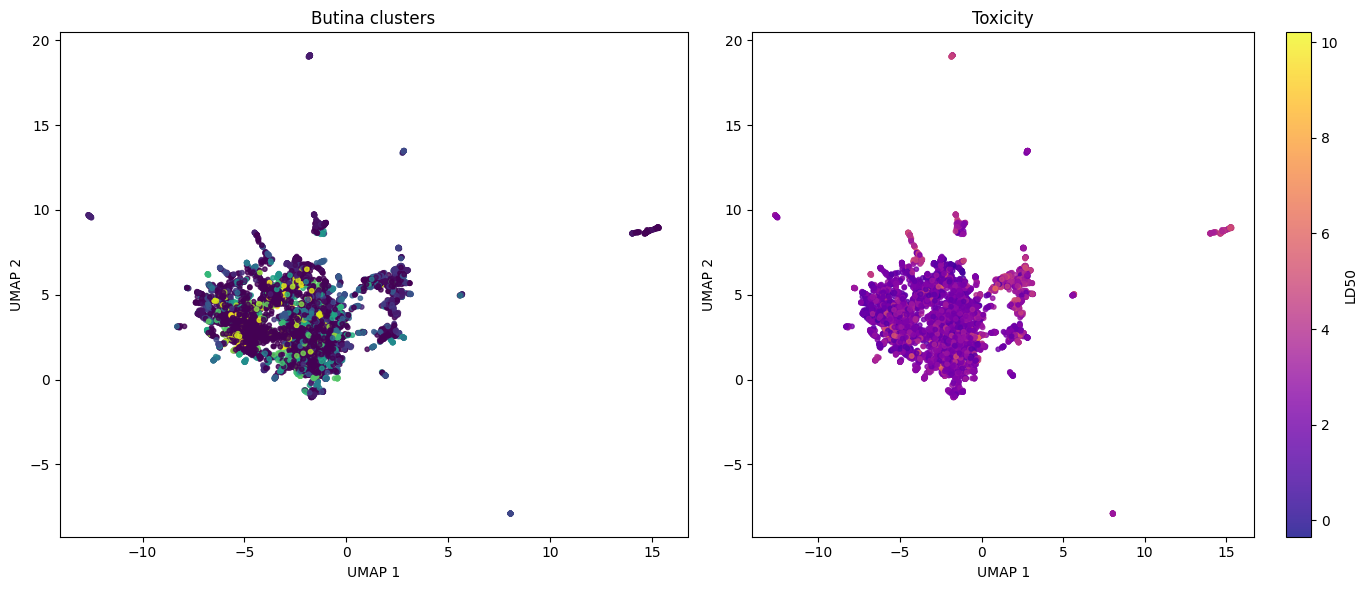

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ax1 = Chemical space and butina clustering
ax1.scatter(
    umap_emb[:,0],
    umap_emb[:,1],
    c=butina_labels,
    cmap="viridis",
    s=10,
    alpha=0.8
)
ax1.set(xlabel ="UMAP 1", ylabel="UMAP 2")
ax1.set_title("Butina clusters")

ax = ax2.scatter(
    umap_emb[:, 0],
    umap_emb[:, 1],
    c=tox["ld_50"],
    cmap="plasma",
    s=10,
    alpha=0.8
)

ax2.set(xlabel ="UMAP 1", ylabel="UMAP 2")
ax2.set_title("Toxicity")

plt.colorbar(ax, ax=ax2, label="LD50")
plt.tight_layout()
plt.show()

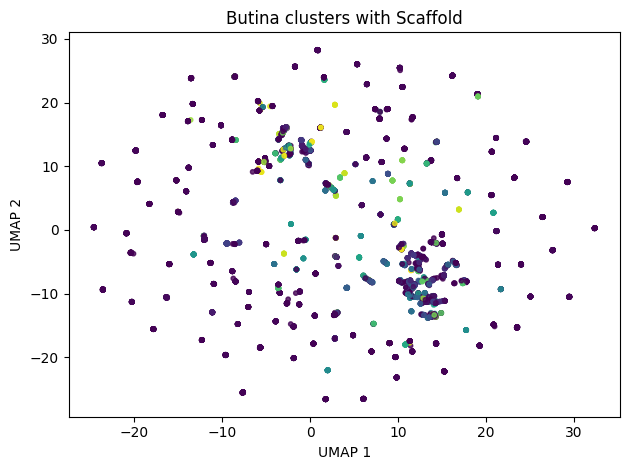

In [35]:
plt.scatter(
    umap_emb2[:, 0],
    umap_emb2[:, 1],
    c=butina_labels2,
    cmap="viridis",
    s=10,
    alpha=0.8
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Butina clusters with Scaffold")

plt.tight_layout()
plt.show()

#### 9) Discussion points
1) How did the scaffolds and functional groups perform in the model performance in comparison the molecular descriptors? Comment on possible reasons. Which combination was suited best?
2) Is the One-Hot Encoding needed in this case?
3) Did the feature filtering (variance, correlation) have an improving effect? Explain!
4) Consider to make this kind of workflow for feature comparison more generally usable: How would a clean solution look? How could you ensure compatibility with other models? How would the function / pipeline look schematically?
5) Visualisation: Using the scaffold fingerprints and the fingerprints for the entire molecule makes a huge difference. What is reason for this effect? Discuss this approach in contrast to similarity thresholds in the Butina clustering.
6) When might scaffolding prove useful?
7) Is toxicity correlated to molecular structure? I.e. what did the toxicity map in UMAP space reveal?


1. Well for a regression it was predictable that functional groups and scaffold would not perform that well in comparsison to molecular descriptors, thus descriptors being the best. For combination, any combination including molecular descriiptors
2. No, I dont think it is needed, as we are already dealing with smiles in the case of the scaffolds
3. Not really, only slightly. Most likely due to many data entries not being redundant/noise.
4. I dont really know what to answer here. I guess just do a pipeline for generaal use with different models which you can specify.
5. Scaffold only contains core ring structures which can reveal morea about the toxicity clusters compared to when also all sidechains and functional groups are present as in the case of fingerprints.
6. When the cause is scaffold-driven, or one wants to build upon a certain structure.
7. I would say it is partially. There larger cluster is more low LD50 values corresponding to higher toxicity and on the edges there are some smaller clusters with higher LD50 values.